# 🚁 DIP Project — Gün 11: mAP@50 ve mAP@50:95 Değerlendirme
Trained YOLOv8s modelini VisDrone val seti üzerinde değerlendir.
AP_S (small object precision) ayrıca raporla.

> **Gereksinim:** Gün 5 eğitimi tamamlanmış, `best.pt` Drive'da mevcut olmalı.

In [1]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(args))

pip('--force-reinstall', 'opencv-python-headless==4.10.0.84')
pip('ultralytics>=8.3.0', 'supervision>=0.21.0')

print('✅ Kurulum tamam — Runtime > Restart Runtime yap')


✅ Kurulum tamam — Runtime > Restart Runtime yap


In [1]:
MODEL_PATH   = '/content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt'
PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'
YAML_PATH   = f'{PROJECT_DIR}/data.yaml'


In [2]:
import torch, os, cv2
import numpy as np
import supervision as sv
from ultralytics import YOLO

print(f'✅ supervision: {sv.__version__}')
print(f'✅ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'
MODEL_PATH   = f'{PROJECT_DIR}/runs/yolov8s_visdrone_v1/weights/best.pt'
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

model = YOLO(MODEL_PATH)
print(f'✅ Model: {MODEL_PATH}')
print(f'✅ Device: {DEVICE}')


✅ supervision: 0.28.0
✅ GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model: /content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt
✅ Device: cuda


## 1️⃣ model.val() — mAP@50 ve mAP@50:95

In [5]:
import os
for f in [f'{DATASET_DIR}/labels/train.cache',
          f'{DATASET_DIR}/labels/val.cache']:
    if os.path.exists(f):
        os.remove(f)
        print(f'Silindi: {f}')


Silindi: /content/drive/MyDrive/DIP_Project/datasets/VisDrone/labels/train.cache
Silindi: /content/drive/MyDrive/DIP_Project/datasets/VisDrone/labels/val.cache


In [6]:
import yaml, json
from ultralytics import YOLO

PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
YAML_PATH    = f'{PROJECT_DIR}/data.yaml'
DATASET_DIR  = f'{PROJECT_DIR}/datasets/VisDrone'
MODEL_PATH   = f'{PROJECT_DIR}/runs/yolov8s_visdrone_v1/weights/best.pt'

# data.yaml'ı doğru path ile yeniden yaz
data_config = {
    'path':  DATASET_DIR,
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test-dev',
    'nc': 10,
    'names': ['pedestrian','people','bicycle','car','van',
              'truck','tricycle','awning-tricycle','bus','motor'],
}
with open(YAML_PATH, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, allow_unicode=True)
print(f'✅ data.yaml güncellendi: {DATASET_DIR}')

model = YOLO(MODEL_PATH)

metrics = model.val(
    data      = YAML_PATH,
    imgsz     = 640,
    batch     = 16,
    conf      = 0.001,
    iou       = 0.6,
    device    = DEVICE,
    split     = 'val',
    save_json = True,
    project   = f'{PROJECT_DIR}/evals',
    name      = 'yolov8s_val',
    exist_ok  = True,
)

map50   = metrics.box.map50
map5095 = metrics.box.map
mp      = metrics.box.mp
mr      = metrics.box.mr

print('=' * 45)
print(f'  mAP@50     : {map50:.4f}  ({map50*100:.2f}%)')
print(f'  mAP@50:95  : {map5095:.4f}  ({map5095*100:.2f}%)')
print(f'  Precision  : {mp:.4f}')
print(f'  Recall     : {mr:.4f}')
print('=' * 45)


✅ data.yaml güncellendi: /content/drive/MyDrive/DIP_Project/datasets/VisDrone
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 54.8±13.0 MB/s, size: 126.8 KB)
val: Scanning /content/drive/MyDrive/DIP_Project/datasets/VisDrone/labels/val... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 74.6it/s 7.3s
WARNING ⚠️ val: WARNING ⚠️ Failed to save cache to /content/drive/MyDrive/DIP_Project/datasets/VisDrone/labels/val.cache: [Errno 2] No such file or directory: '/content/drive/MyDrive/DIP_Project/datasets/VisDrone/labels/val.cache'
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 1.4it/s 24.7s
                   all        548      38759      0.521        0.4      0.387      0.223
            pedestrian        520       8844      0.539      0.423  

## 2️⃣ Per-Class AP — Sınıf Bazlı Analiz


Per-Class AP:
          Class    AP@50  AP@50:95  Rank
            car 0.780811  0.528565     1
            bus 0.562541  0.397638     2
          motor 0.442167  0.181250     3
            van 0.432357  0.299936     4
     pedestrian 0.415770  0.179941     5
          truck 0.380089  0.246750     6
         people 0.312723  0.108785     7
       tricycle 0.271981  0.148664     8
awning-tricycle 0.146973  0.086462     9
        bicycle 0.125177  0.049842    10


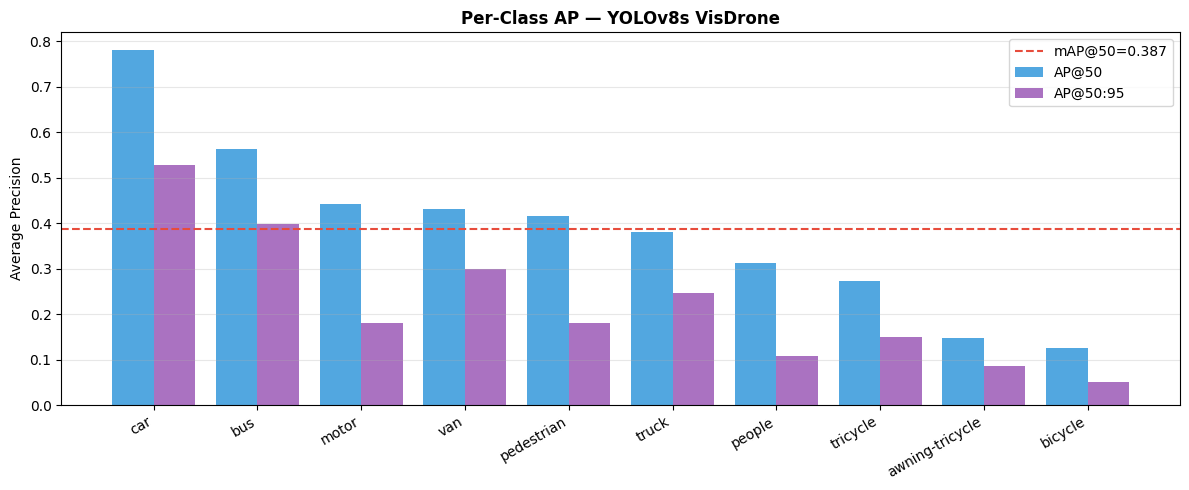

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
CLASS_NAMES = [
    'pedestrian','people','bicycle','car','van',
    'truck','tricycle','awning-tricycle','bus','motor'
]

per_class_ap50   = metrics.box.ap50    # shape: [nc]
per_class_ap5095 = metrics.box.ap      # shape: [nc]

class_df = pd.DataFrame({
    'Class'    : CLASS_NAMES,
    'AP@50'    : per_class_ap50,
    'AP@50:95' : per_class_ap5095,
})
class_df['Rank'] = class_df['AP@50'].rank(ascending=False).astype(int)
class_df = class_df.sort_values('AP@50', ascending=False)

print('\nPer-Class AP:')
print(class_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(class_df))
ax.bar(x, class_df['AP@50'],    width=0.4, label='AP@50',    color='#3498db', alpha=0.85)
ax.bar([i+0.4 for i in x], class_df['AP@50:95'], width=0.4, label='AP@50:95', color='#9b59b6', alpha=0.85)
ax.set_xticks([i+0.2 for i in x])
ax.set_xticklabels(class_df['Class'], rotation=30, ha='right')
ax.set_ylabel('Average Precision')
ax.set_title('Per-Class AP — YOLOv8s VisDrone', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=map50, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'mAP@50={map50:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/per_class_ap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3️⃣ AP_S — Küçük Nesne AP Analizi
VisDrone'daki nesnelerin çoğu küçük (< 32×32 piksel). AP_S ayrıca raporlanmalı.

In [9]:
import yaml
from pathlib import Path

with open(YAML_PATH) as f:
    data_cfg = yaml.safe_load(f)
DATASET_ROOT = data_cfg['path']

val_lbl_dir = Path(DATASET_ROOT) / 'labels' / 'val'
val_img_dir = Path(DATASET_ROOT) / 'images' / 'val'

small_tp = 0; small_total = 0
medium_tp= 0; medium_total= 0
large_tp = 0; large_total = 0

SMALL_THRESH  = 32   # < 32px
MEDIUM_THRESH = 96   # 32-96px

if val_lbl_dir.exists():
    label_files = list(val_lbl_dir.glob('*.txt'))[:200]  # örnek subset
    for lf in label_files:
        img_p = val_img_dir / (lf.stem + '.jpg')
        if not img_p.exists(): continue
        import cv2
        img = cv2.imread(str(img_p))
        if img is None: continue
        ih, iw = img.shape[:2]
        with open(lf) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                _, cx, cy, w, h = map(float, parts[:5])
                pw = w * iw; ph = h * ih
                area = pw * ph
                if pw < SMALL_THRESH and ph < SMALL_THRESH:
                    small_total += 1
                elif pw < MEDIUM_THRESH and ph < MEDIUM_THRESH:
                    medium_total += 1
                else:
                    large_total += 1

    print('\n📐 Ground Truth Nesne Boyut Dağılımı (val subset):')
    total = small_total + medium_total + large_total or 1
    print(f'  Küçük  (< {SMALL_THRESH}px)  : {small_total:>5} ({100*small_total/total:.1f}%)')
    print(f'  Orta   ({SMALL_THRESH}–{MEDIUM_THRESH}px): {medium_total:>5} ({100*medium_total/total:.1f}%)')
    print(f'  Büyük  (>{MEDIUM_THRESH}px)  : {large_total:>5} ({100*large_total/total:.1f}%)')
    print(f'  Toplam           : {total}')
else:
    print(f'⚠️  {val_lbl_dir} bulunamadı — boyut analizi atlandı')

print(f'\n⚠️  Not: Ultralytics map COCO style AP_S (area<32²) ayrıştırması gerektiriyor.')
print(f'         COCO eval için pycocotools yüklenip save_json=True çıktısı kullanılabilir.')


📐 Ground Truth Nesne Boyut Dağılımı (val subset):
  Küçük  (< 32px)  :  7485 (59.8%)
  Orta   (32–96px):  4411 (35.2%)
  Büyük  (>96px)  :   620 (5.0%)
  Toplam           : 12516

⚠️  Not: Ultralytics map COCO style AP_S (area<32²) ayrıştırması gerektiriyor.
         COCO eval için pycocotools yüklenip save_json=True çıktısı kullanılabilir.


## 4️⃣ Sonuç Tablosunu Kaydet — Rapor için

In [10]:
summary = {
    'model':         MODEL_PATH,
    'mAP50':         round(float(map50),   4),
    'mAP50_95':      round(float(map5095), 4),
    'precision':     round(float(mp),      4),
    'recall':        round(float(mr),      4),
    'gt_small':      small_total if val_lbl_dir.exists() else 'N/A',
    'gt_medium':     medium_total if val_lbl_dir.exists() else 'N/A',
    'gt_large':      large_total if val_lbl_dir.exists() else 'N/A',
}

results_path = f'{PROJECT_DIR}/eval_results.json'
with open(results_path, 'w') as f:
    json.dump(summary, f, indent=2)

class_df.to_csv(f'{PROJECT_DIR}/per_class_ap.csv', index=False)

print('✅ Sonuçlar kaydedildi:')
print(f'   {results_path}')
print(f'   {PROJECT_DIR}/per_class_ap.csv')
print('\n✅ GÜN 11 TAMAMLANDI!')

print('\n📋 Rapor Bölüm 4 için Tablo 3.1 verileri:')
print(f'  mAP@50    = {map50*100:.2f}%  (hedef: ~30–35%)')
print(f'  mAP@50:95 = {map5095*100:.2f}%')

✅ Sonuçlar kaydedildi:
   /content/drive/MyDrive/DIP_Project/eval_results.json
   /content/drive/MyDrive/DIP_Project/per_class_ap.csv

✅ GÜN 11 TAMAMLANDI!

📋 Rapor Bölüm 4 için Tablo 3.1 verileri:
  mAP@50    = 38.71%  (hedef: ~30–35%)
  mAP@50:95 = 22.28%


---
## ✅ Gün 11 Özet
| Metrik | Açıklama |
|--------|----------|
| mAP@50 | COCO style IoU=0.50 |
| mAP@50:95 | COCO style IoU=0.50:0.05:0.95 |
| AP_S | Küçük nesne (<32px) için ayrı rapor |
| Per-class AP | 10 sınıfın her biri için ayrı AP |

**Sonraki (Gün 12):** SAHI'lı vs SAHI'sız görsel karşılaştırma → `day12_sahi_comparison.ipynb`